In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')

In [2]:
from analysis.position_sd import get_neuron_positions, compute_2d_histogram
from analysis.firing_sd import cv2, fano_factor, synchrony_index, mean_firing_rates
from load_data.load_npz import load_spikedata
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import os
import numpy as np


In [3]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [4]:
full_colors = ["green", "lime", "royalblue", "cyan"]

In [19]:
fano_factor_24578_49 = fano_factor(sd24578_49)
fano_factor_24578_60 = fano_factor(sd24578_60)
fano_factor_24481_49 = fano_factor(sd24481_49)
fano_factor_24481_60 = fano_factor(sd24481_60)

In [20]:
fano_factors = [fano_factor_24481_49, fano_factor_24481_60, fano_factor_24578_49, fano_factor_24578_60]
fano_labels = ["24481 D49", "24481 D60", "24578 D49", "24578 D60"]

In [23]:
def plot_violin(data_list, labels, colors, output_path=None):
    """
    Create a violin plot for each dataset in data_list on the same axes.
    
    Parameters:
      data_list : list of array-like
          A list of numerical data arrays, one per group.
      labels : list of str
          Labels for each dataset to be used as x-axis tick labels.
      colors : list of color
          Colors for each violin. Must have the same length as data_list.
      output_path : str, optional
          If provided, the figure is saved to this path. Otherwise, it is shown.
    """
    fig, ax = plt.subplots(figsize=(8,6))
    vp = ax.violinplot(data_list, showmeans=True, showmedians=False, showextrema=True)
    
    # Customize each violin with the specified colors.
    for i, violin in enumerate(vp['bodies']):
        violin.set_facecolor(colors[i])
        violin.set_edgecolor('black')
        violin.set_alpha(0.7)
    
    # Optionally, customize the medians and means.
    if 'cmedians' in vp:
        vp['cmedians'].set_color('black')
    if 'cmeans' in vp:
        vp['cmeans'].set_color('black')
    
    # Set the x-axis tick labels.
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    
    ax.set_title("Fano Factors")
    ax.set_ylabel("Fano Factor")
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path)
        plt.close(fig)
        print(f"Saved violin plot to {output_path}")
    else:
        plt.show()


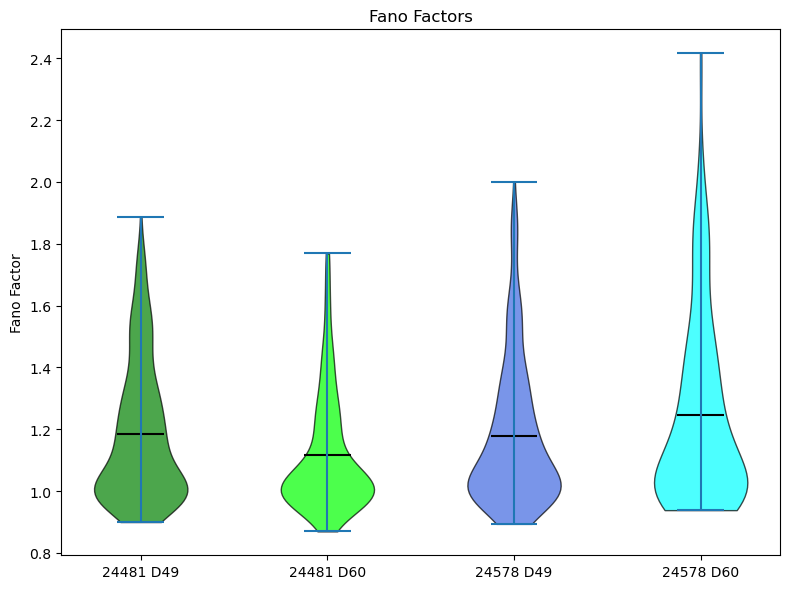

In [ ]:
plot_violin(fano_factors, fano_labels, full_colors)

In [7]:
def summarize_firing_metrics(sd_list, dataset_names):
    """
    For each SpikeData in sd_list, compute summary statistics for various firing metrics.
    Metrics include:
      - Mean Firing Rate (Hz) per neuron (using mean_firing_rates(sd))
      - Median Interspike Interval (ms) per neuron (from sd.interspike_intervals())
      - CV2 per neuron (using your cv2 function, computed per neuron)
    
    Parameters:
      sd_list : list of SpikeData
          A list of SpikeData objects.
      dataset_names : list of str
          Names/labels for each dataset.
          
    Returns:
      summary_list : list of dict
          Each dict contains the dataset name and summary stats for each metric.
    """
    summary_list = []
      
    for i, sd in enumerate(sd_list):
        dataset_name = dataset_names[i] if i < len(dataset_names) else f"Dataset_{i+1}"
        
        # Mean Firing Rate per neuron:
        mean_rates = mean_firing_rates(sd)  # Assume returns a 1D array
        
        # Compute ISIs per neuron (sd.interspike_intervals() returns a list of arrays)
        isi_list = sd.interspike_intervals()  # Each element is an array of ISIs (ms)
        median_isis = np.array([np.median(isi) if len(isi) > 0 else np.nan for isi in isi_list])
        
        # Compute CV2 for each neuron using cv2(sd, neuron) for each neuron index
        cv2_array = cv2(sd)

        #compute fano factors
        fano_factors = fano_factor(sd)
        
        synchrony_index = synchrony_index(sd, window_size=50)
        

        # Build summary stats:
        summary_dict = {
            "dataset": dataset_name,
            "N_neurons": len(mean_rates),
            "mean_FR_mean": float(np.nanmean(mean_rates)),
            "mean_FR_std": float(np.nanstd(mean_rates)),
            "median_ISI_mean": float(np.nanmean(median_isis)),
            "median_ISI_std": float(np.nanstd(median_isis)),
            "CV2_mean": float(np.nanmean(cv2_array)),
            "CV2_std": float(np.nanstd(cv2_array)),
            "FR_min": float(np.nanmin(mean_rates)),
            "FR_max": float(np.nanmax(mean_rates)),
            "fano_factor_mean": float(np.nanmean(fano_factors)),
            "fano_factor_std": float(np.nanstd(fano_factors)),
            "synchrony_index_mean": float(np.nanmean(synchrony_index)),
            "synchrony_index_std": float(np.nanstd(synchrony_index))
        }
        summary_list.append(summary_dict)
    
    return summary_list



In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_avalanche_distributions(
    sd_list, 
    labels, 
    quantile=0.35, 
    bin_size=40, 
    output_path=None
):
    """
    For each SpikeData in sd_list:
      1) Compute the spike count threshold from the given quantile on the binned data.
      2) Extract avalanche durations and sizes via avalanche_duration_size().
      3) Plot the avalanche size and duration distributions in log–log space.
    
    We produce a single figure with two subplots:
      - Left subplot: Avalanche size distribution (log–log).
      - Right subplot: Avalanche duration distribution (log–log).
    
    Parameters:
      sd_list : list of SpikeData
          Each SpikeData object should have the methods:
            .binned(bin_size) -> array of spike counts
            .avalanche_duration_size(thresh, bin_size=40) -> (durations, sizes)
      labels : list of str
          Labels for each dataset (same length as sd_list). 
          E.g. ["24481 D49", "24481 D60", "24578 D49", "24578 D60"].
      quantile : float, default 0.35
          The quantile used to compute the spike count threshold.
      bin_size : int, default 40
          Bin size (ms) for binning spikes and detecting avalanches.
      output_path : str or None
          If provided, save the resulting figure to this path. Otherwise show interactively.
    
    """
    fig, (ax_size, ax_dur) = plt.subplots(1, 2, figsize=(12, 5))
    
    for i, sd in enumerate(sd_list):
        label = labels[i] if i < len(labels) else f"Dataset_{i+1}"
        
        # 1) Compute spike-count threshold from the given quantile
        binned_spikes = sd.binned(bin_size)
        thresh = np.quantile(binned_spikes, quantile)
        
        # 2) Extract avalanche durations and sizes
        durations, sizes = sd.avalanche_duration_size(thresh, bin_size)
        
        if len(durations) == 0:
            # If no avalanches, skip or plot a placeholder
            print(f"{label}: No avalanches found with thresh={thresh:.2f}")
            continue
        
        # 3) Plot distributions in log–log space
        #    We'll do a simple histogram for sizes, durations, then plot in log–log.
        
        # For avalanche sizes
        size_counts = {}
        for s in sizes:
            size_counts[s] = size_counts.get(s, 0) + 1
        
        # Sort by size
        unique_sizes = np.array(sorted(size_counts.keys()))
        freq_sizes = np.array([size_counts[s] for s in unique_sizes])
        
        ax_size.plot(unique_sizes, freq_sizes, marker='o', linestyle='-', label=label)
        
        # For avalanche durations
        dur_counts = {}
        for d in durations:
            dur_counts[d] = dur_counts.get(d, 0) + 1
        
        unique_durs = np.array(sorted(dur_counts.keys()))
        freq_durs = np.array([dur_counts[d] for d in unique_durs])
        
        ax_dur.plot(unique_durs, freq_durs, marker='o', linestyle='-', label=label)
    
    # Format the subplots in log–log
    ax_size.set_xscale('log')
    ax_size.set_yscale('log')
    ax_size.set_xlabel("Avalanche Size (spike count)")
    ax_size.set_ylabel("Frequency")
    ax_size.set_title("Avalanche Size Distribution")
    ax_size.legend(loc='best')
    
    ax_dur.set_xscale('log')
    ax_dur.set_yscale('log')
    ax_dur.set_xlabel("Avalanche Duration (bins)")
    ax_dur.set_ylabel("Frequency")
    ax_dur.set_title("Avalanche Duration Distribution")
    ax_dur.legend(loc='best')
    
    plt.suptitle(f"Avalanche Distributions (quantile={quantile}, bin_size={bin_size} ms)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if output_path:
        plt.savefig(output_path)
        plt.close(fig)
        print(f"Saved avalanche distributions to: {output_path}")
    else:
        plt.show()


In [6]:
sd_list = [sd24481_49, sd24481_60, sd24578_49, sd24578_60]
labels = ["24481 D49", "24481 D60", "24578 D49", "24578 D60"]

In [7]:
sd481_list = [sd24481_49, sd24481_60]
sd578_list = [sd24578_49, sd24578_60]
label481 = ["24481 D49", "24481 D60"]
label578 = ["24578 D49", "24578 D60"]


ValueError: Quantiles must be in the range [0, 1]

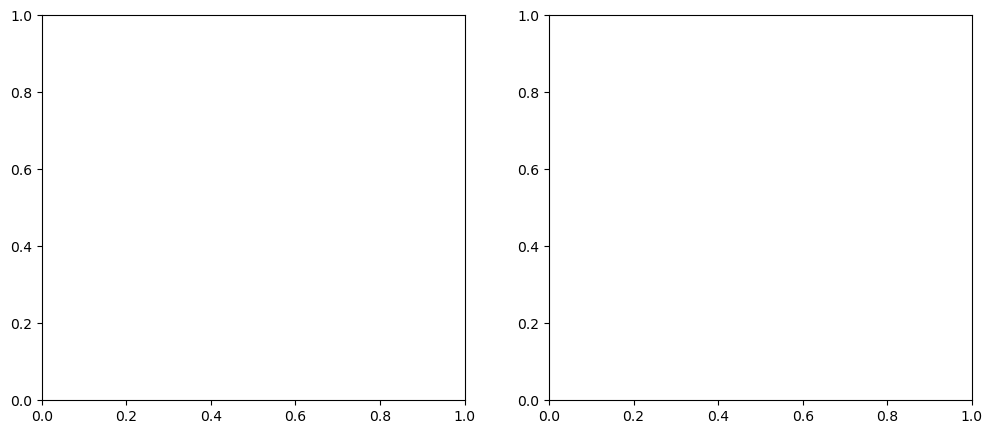

In [8]:
plot_avalanche_distributions(
    sd481_list, 
    label481, 
    quantile=4, 
    bin_size=1, 
    output_path=None)

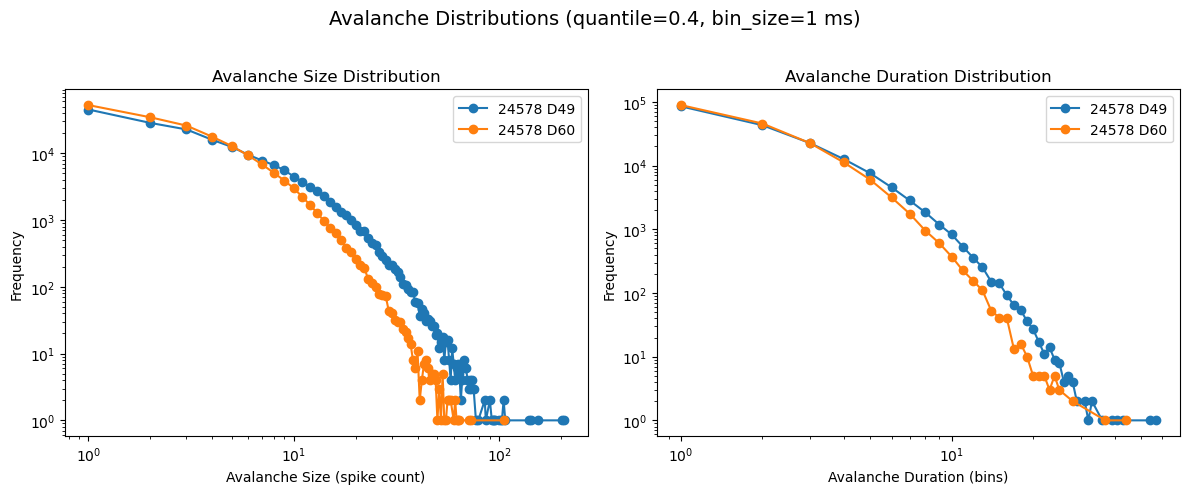

In [50]:
plot_avalanche_distributions(
    sd578_list, 
    label578, 
    quantile=0.4, 
    bin_size=1, 
    output_path=None)

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def plot_avalanche_distributions2(sd, thresh, bin_size=40, label=None):
    """
    Bin the spikes into avalanches, compute their durations and sizes, and plot
    the distributions as log-log histograms.
    
    Parameters:
      sd : SpikeData object
          The spikedata instance.
      thresh : float
          The threshold for detecting avalanches.
      bin_size : int, optional
          Bin size for spike binning (default 40 ms).
      label : str, optional
          A label to include in the titles.
          
    If no avalanches are detected, a message is printed and nothing is plotted.
    """
    durations, sizes = sd.avalanche_duration_size(thresh, bin_size)
    
    if len(durations) == 0 or len(sizes) == 0:
        print(f"No avalanches detected for label '{label}' with thresh={thresh} and bin_size={bin_size}.")
        return
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Create bins for size histogram
    size_bins = np.logspace(np.log10(1), np.log10(max(sizes)+1), 30)
    axs[0].hist(sizes, bins=size_bins, density=True, color='skyblue', alpha=0.7)
    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    axs[0].set_xlabel("Avalanche Size")
    axs[0].set_ylabel("Probability Density")
    axs[0].set_title(f"Avalanche Sizes{' - ' + label if label else ''}")
    
    # Create bins for duration histogram
    duration_bins = np.logspace(np.log10(1), np.log10(max(durations)+1), 30)
    axs[1].hist(durations, bins=duration_bins, density=True, color='salmon', alpha=0.7)
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xlabel("Avalanche Duration")
    axs[1].set_ylabel("Probability Density")
    axs[1].set_title(f"Avalanche Durations{' - ' + label if label else ''}")
    
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_avalanche_distributions(sd24481_49, thresh=0.25, bin_size=40, label="24481 D49")


def plot_size_vs_duration(sd, thresh, bin_size=40, label=None):
    durations, sizes = sd.avalanche_duration_size(thresh, bin_size)
    
    plt.figure(figsize=(6,5))
    plt.scatter(durations, sizes, alpha=0.5)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Avalanche Duration")
    plt.ylabel("Avalanche Size")
    plt.title(f"Size vs. Duration{' - ' + label if label else ''}")
    plt.grid(True, which="both", ls="--")
    plt.show()
def plot_dcc_comparison(sd_list, labels, bin_size=40, quantile=0.35):
    dccs = []
    for sd in sd_list:
        result = sd.deviation_from_criticality(quantile=quantile, bin_size=bin_size)
        dccs.append(result.dcc)

    plt.figure(figsize=(8,5))
    plt.bar(labels, dccs, color='orchid')
    plt.ylabel("Deviation from Criticality (DCC)")
    plt.title("DCC Across Conditions")
    plt.tight_layout()
    plt.show()


In [68]:
plot_size_vs_duration(sd24481_49, thresh=0.25, bin_size=40, label="24481 D49")

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 600x500 with 1 Axes>